Effective parameters:
  decimate_factor: 1
  tau_eff: 8
  kmax_eff: 200
  locked fit window: 10 60
  min_tsep_eff_list: [8, 16, 50]
  n_surrogates: 199
  iaaft_iters: 200
  n_workers: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=106944 | fs_eff=1000 Hz | segment=[814.571,921.515] s
LOCKED fit window: k=[10,60] ~ [0.0100,0.0600] s
Observed | min_tsep=8 | obs=5.17405 1/s | R2=0.4367 | RMSE=0.0865 | pairs=6000
Observed | min_tsep=16 | obs=5.17405 1/s | R2=0.4367 | RMSE=0.0865 | pairs=6000
Observed | min_tsep=50 | obs=5.17994 1/s | R2=0.4387 | RMSE=0.08625 | pairs=6000
Running 199 IAAFT surrogates with 6 workers...
  completed 25/199 surrogates | failed=0
  completed 50/199 surrogates | failed=0
  completed 75/199 surrogates | failed=0
  completed 100/199 surrogates | failed=0
  completed 125/199 surrogates | failed=0
  completed 150/199 surrogates | failed=0
  completed 1

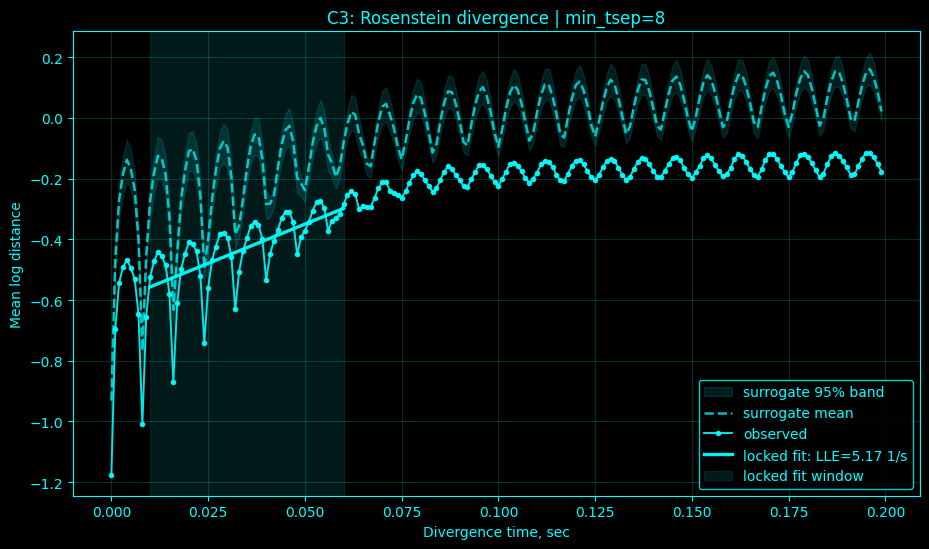

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep8_C3_m10_tau8_nS199_20260603_154926.png


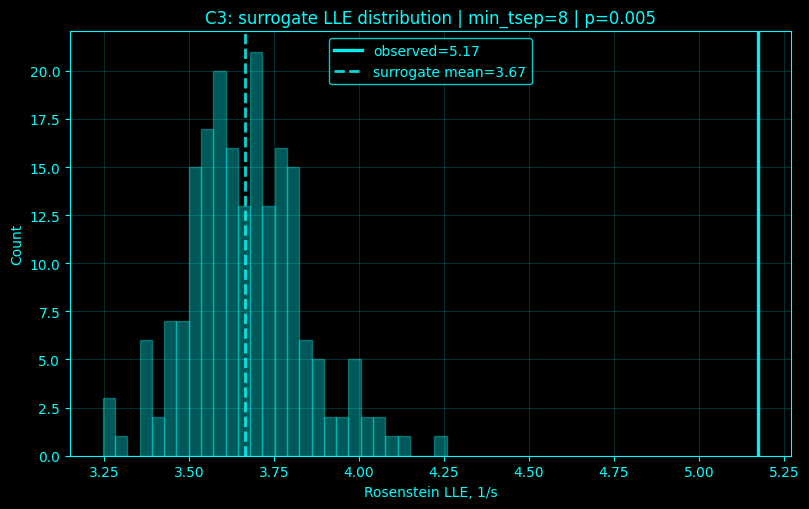

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep8_C3_m10_tau8_nS199_20260603_154926.png


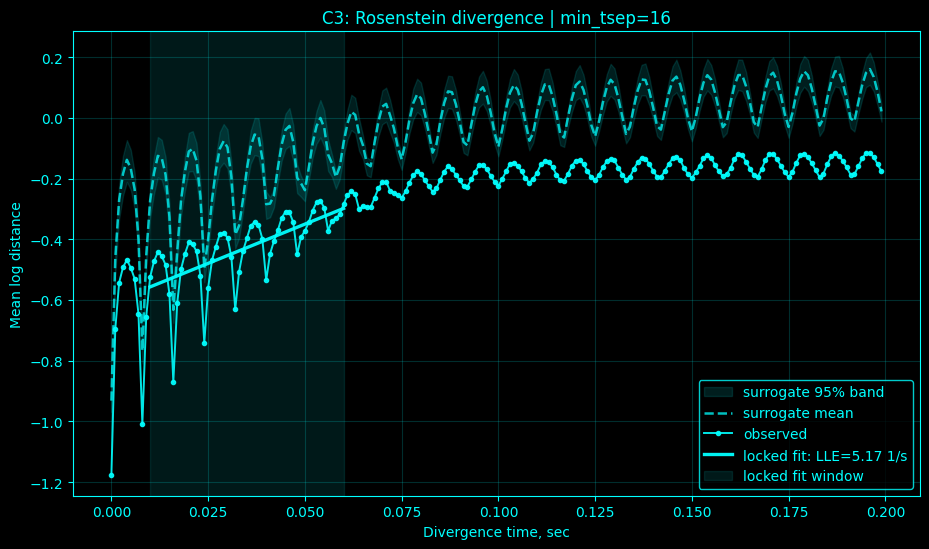

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep16_C3_m10_tau8_nS199_20260603_154926.png


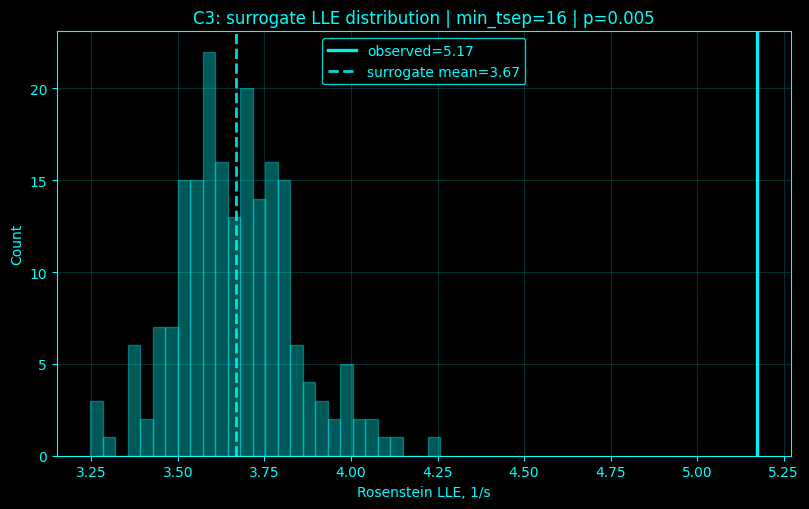

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep16_C3_m10_tau8_nS199_20260603_154926.png


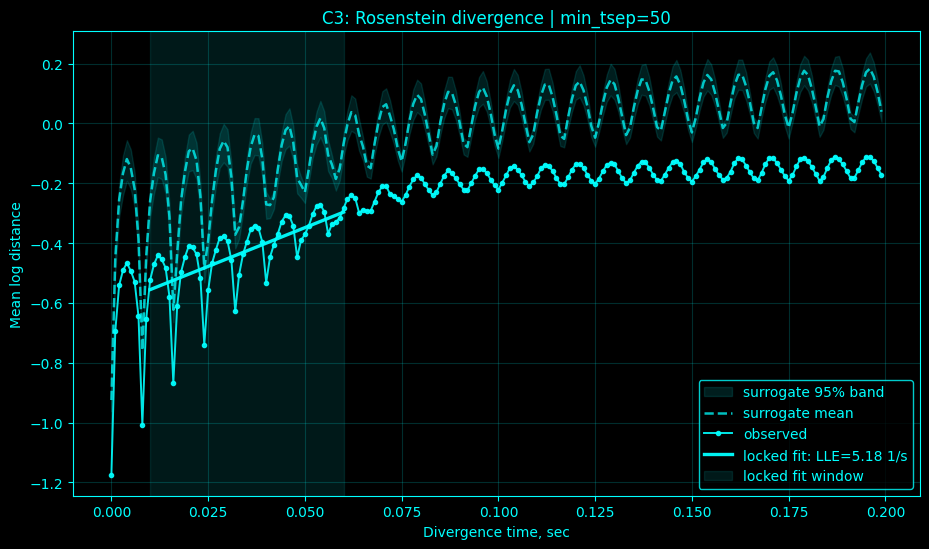

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/01_C3_divergence_tsep50_C3_m10_tau8_nS199_20260603_154926.png


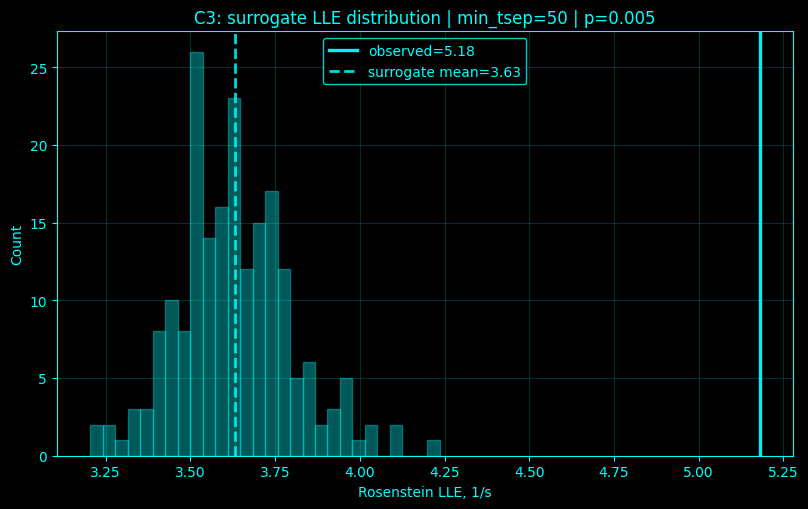

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/02_C3_surrogate_hist_tsep50_C3_m10_tau8_nS199_20260603_154926.png


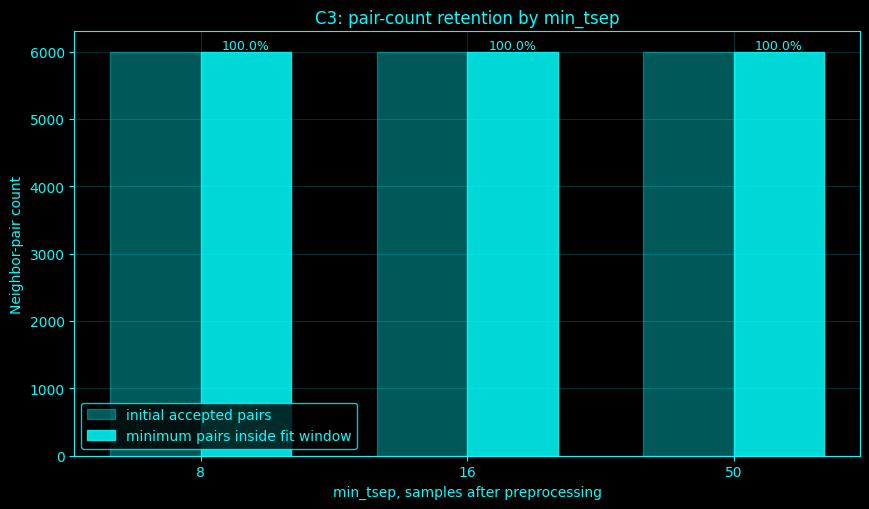

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/03A_C3_pair_count_retention_summary_C3_m10_tau8_nS199_20260603_154926.png


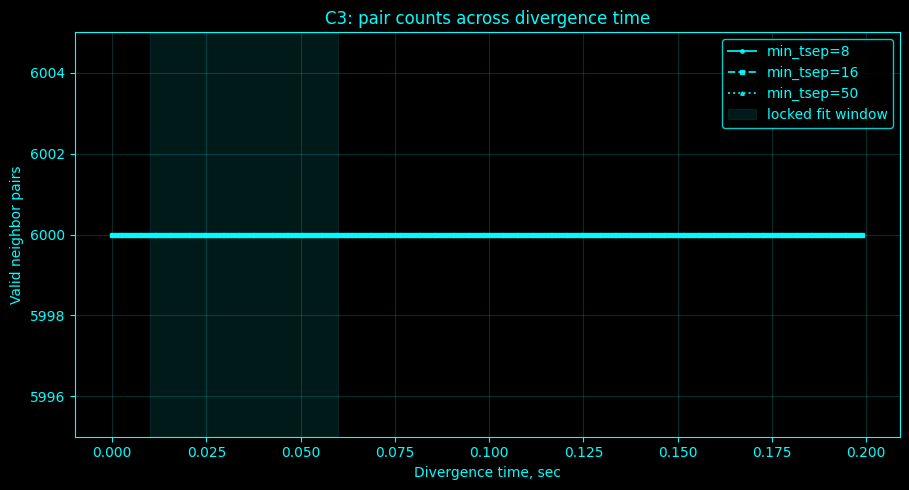

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/03B_C3_pair_counts_zoomed_by_k_C3_m10_tau8_nS199_20260603_154926.png


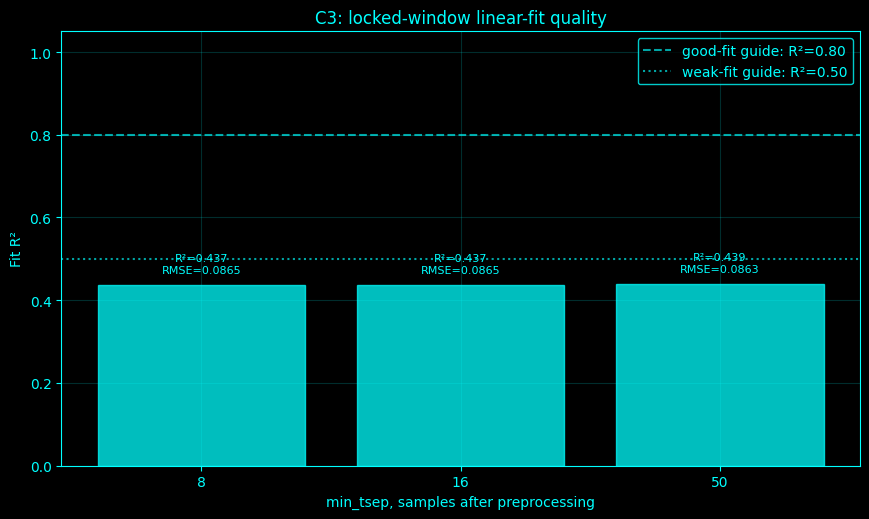

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/04_C3_fit_quality_r2_rmse_by_min_tsep_C3_m10_tau8_nS199_20260603_154926.png


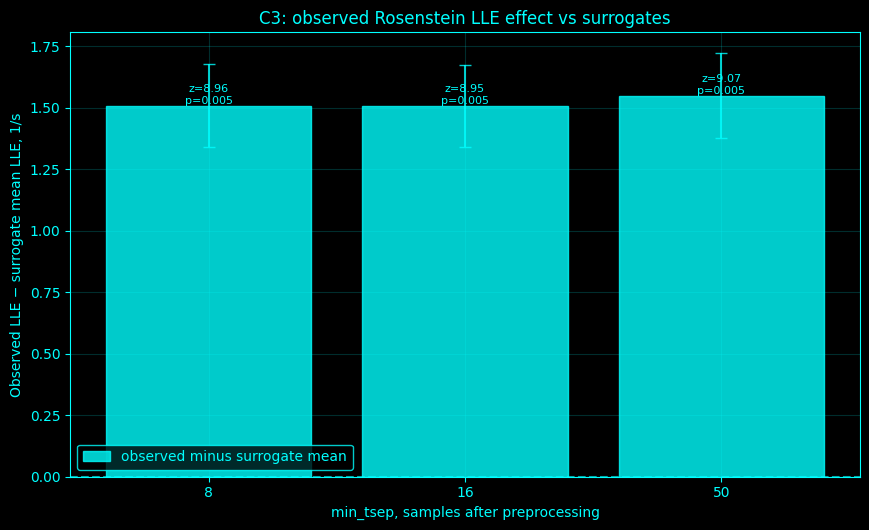

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/05A_C3_LLE_effect_size_vs_surrogates_C3_m10_tau8_nS199_20260603_154926.png


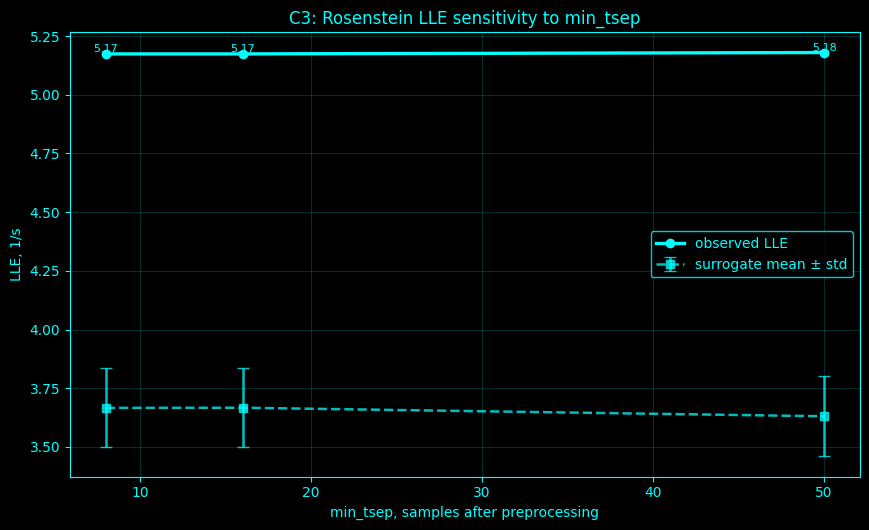

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_sweep_locked_window_moreS_fast/plots/05B_C3_LLE_sensitivity_annotated_C3_m10_tau8_nS199_20260603_154926.png

=== Rosenstein more-surrogate summary ===
channel  min_tsep  min_tsep_seconds  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  n_surrogates_requested  n_surrogates_completed  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  initial_pair_count  fit_window_min_pair_count  fit_window_median_pair_count  final_nonzero_pair_count  pair_retention_percent  fs_eff  emb_dim  tau_eff  kmax_eff  fit_lo_eff  fit_hi_eff  n_ref  k_query_base  decimate_factor  max_samples  iaaft_iters  iaaft_tol
     C3         8             0.008 5.174052       3.666374      0.168285       3.362645       4.024972             8.959079              0.005           0.005                     199                     199    0.436696      0.086498    

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
t0, t1 = 814.571, 921.515
start_idx, end_idx = int(t0 * fs_original), int(t1 * fs_original)

emb_dim = 10
tau_original = 8

fit_lo_original = 10
fit_hi_original = 60

min_tsep_original_list = [tau_original, 2 * tau_original, 50]

n_ref = 6000
kmax_original = 200
k_query_base = 80
min_pairs_required = 100

n_surrogates = _speed_count(199, minimum=20)
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20

seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None

standardize = True
linear_detrend = False

results_dir = os.path.join(base_dir, "results", "rosenstein_sweep_locked_window_moreS_fast")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"C3_m{emb_dim}_tau{tau_original}_nS{n_surrogates}_{timestamp}"

OUT_SUMMARY_CSV = os.path.join(results_dir, f"rosenstein_moreS_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"rosenstein_moreS_surrogates_{tag}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"rosenstein_moreS_curves_{tag}.csv")
OUT_DIAG_CSV = os.path.join(results_dir, f"rosenstein_moreS_diagnostics_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"rosenstein_moreS_qc_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"rosenstein_moreS_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"summary_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for t in leg.get_texts():
            t.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def fit_slope_locked(ks, log_div, fit_lo, fit_hi, fs_eff):
    fit_lo = int(fit_lo)
    fit_hi = int(fit_hi)
    if fit_hi <= fit_lo:
        raise ValueError(f"Invalid fit window: fit_lo={fit_lo}, fit_hi={fit_hi}")
    if fit_hi >= len(ks):
        raise ValueError(f"fit_hi={fit_hi} outside curve length={len(ks)}")
    xw = ks[fit_lo:fit_hi + 1]
    yw = log_div[fit_lo:fit_hi + 1]
    ok = np.isfinite(xw) & np.isfinite(yw)
    xw = xw[ok]
    yw = yw[ok]
    if len(xw) < 5:
        raise ValueError("Too few finite points in fit window.")
    coef = np.polyfit(xw, yw, 1)
    yhat = np.polyval(coef, xw)
    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def rosenstein_curves_multi_tsep(x, m, tau, min_tsep_list, n_ref, kmax, seed=0, k_query_base=80, min_pairs_required=100):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    M = len(X)
    valid_max = M - kmax - 1
    if valid_max <= 10:
        raise ValueError(f"Too few embedded points for kmax={kmax}. Embedded M={M}.")
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx
    max_tsep = int(max(min_tsep_list))
    k_query = min(M, max(k_query_base, max_tsep + 40, 4 * m + 20))
    nn = NearestNeighbors(n_neighbors=k_query, algorithm="auto").fit(X)
    _, inds = nn.kneighbors(X[ref_idx])
    ks = np.arange(kmax, dtype=int)
    curves = {}
    counts = {}
    pair_counts = {}
    for min_tsep in min_tsep_list:
        min_tsep = int(min_tsep)
        nn_idx = np.full(len(ref_idx), -1, dtype=int)
        for a, i in enumerate(ref_idx):
            for cand in inds[a, 1:]:
                cand = int(cand)
                if cand >= valid_max:
                    continue
                if abs(cand - int(i)) > min_tsep:
                    nn_idx[a] = cand
                    break
        keep = nn_idx >= 0
        ref_keep = ref_idx[keep]
        nn_keep = nn_idx[keep]
        pair_counts[min_tsep] = int(len(ref_keep))
        if len(ref_keep) < min_pairs_required:
            raise ValueError(f"Too few pairs after Theiler exclusion for min_tsep={min_tsep}: {len(ref_keep)} pairs.")
        log_div = np.full(kmax, np.nan, dtype=float)
        count_k = np.zeros(kmax, dtype=int)
        for k in range(kmax):
            i = ref_keep + k
            j = nn_keep + k
            ok = (i < M) & (j < M)
            if not np.any(ok):
                continue
            dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
            dist = np.maximum(dist, 1e-12)
            log_div[k] = float(np.mean(np.log(dist)))
            count_k[k] = int(np.sum(ok))
        curves[min_tsep] = log_div
        counts[min_tsep] = count_k
    return ks, curves, counts, pair_counts

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

def add_fit_line(ax, ks, log_div, fit_lo, fit_hi, slope, intercept, fs_eff, label):
    kfit = ks[fit_lo:fit_hi + 1]
    yfit = slope * kfit + intercept
    ax.plot(kfit / fs_eff, yfit, color=ACCENT, linewidth=2.4, alpha=0.95, label=label)

tau_eff = effective_sample_param(tau_original, decimate_factor, minimum=1)
kmax_eff = effective_sample_param(kmax_original, decimate_factor, minimum=20)
fit_lo_eff = effective_sample_param(fit_lo_original, decimate_factor, minimum=1)
fit_hi_eff = effective_sample_param(fit_hi_original, decimate_factor, minimum=fit_lo_eff + 5)
min_tsep_eff_list = sorted(set([effective_sample_param(v, decimate_factor, minimum=1) for v in min_tsep_original_list]))

if fit_hi_eff >= kmax_eff:
    fit_hi_eff = kmax_eff - 2
if fit_hi_eff <= fit_lo_eff:
    fit_hi_eff = min(kmax_eff - 2, fit_lo_eff + 10)

print("Effective parameters:")
print("  decimate_factor:", decimate_factor)
print("  tau_eff:", tau_eff)
print("  kmax_eff:", kmax_eff)
print("  locked fit window:", fit_lo_eff, fit_hi_eff)
print("  min_tsep_eff_list:", min_tsep_eff_list)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
diagnostic_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "min_tsep_eff_list": np.array(min_tsep_eff_list, dtype=int),
    "tau_eff": np.array([tau_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "fit_lo_eff": np.array([fit_lo_eff], dtype=int),
    "fit_hi_eff": np.array([fit_hi_eff], dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)

    ch_i = channel_names.index(channel)
    x_raw = EEG[start_idx:end_idx, ch_i].astype(float)

    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )

    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment=[{t0},{t1}] s", flush=True)
    print(f"LOCKED fit window: k=[{fit_lo_eff},{fit_hi_eff}] ~ [{fit_lo_eff/fs_eff:.4f},{fit_hi_eff/fs_eff:.4f}] s", flush=True)

    ks_obs, obs_curves, obs_counts, obs_pair_counts = rosenstein_curves_multi_tsep(
        x,
        m=emb_dim,
        tau=tau_eff,
        min_tsep_list=min_tsep_eff_list,
        n_ref=n_ref,
        kmax=kmax_eff,
        seed=seed,
        k_query_base=k_query_base,
        min_pairs_required=min_pairs_required
    )

    obs_fit = {}

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        slope, intercept, lle_obs, r2, rmse = fit_slope_locked(
            ks_obs,
            ld,
            fit_lo_eff,
            fit_hi_eff,
            fs_eff
        )
        obs_fit[min_tsep] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "lle_per_second": lle_obs,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
        print(f"Observed | min_tsep={min_tsep} | obs={lle_obs:.6g} 1/s | R2={r2:.4f} | RMSE={rmse:.4g} | pairs={obs_pair_counts[min_tsep]}", flush=True)

    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)

    surr_lle_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_curve_by_tsep = {int(t): [] for t in min_tsep_eff_list}
    surr_errors = []
    surr_iters = []

    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )

        ks_s, s_curves, s_counts, s_pair_counts = rosenstein_curves_multi_tsep(
            y,
            m=emb_dim,
            tau=tau_eff,
            min_tsep_list=min_tsep_eff_list,
            n_ref=n_ref,
            kmax=kmax_eff,
            seed=seed + 1000 + s,
            k_query_base=k_query_base,
            min_pairs_required=min_pairs_required
        )

        out = {
            "surrogate_index": int(s + 1),
            "final_error": float(final_err),
            "used_iters": int(used_iters),
            "curves": {},
            "fits": {},
            "pair_counts": {},
        }

        for min_tsep in min_tsep_eff_list:
            min_tsep = int(min_tsep)
            ld_s = s_curves[min_tsep]
            slope_s, intercept_s, lle_s, r2_s, rmse_s = fit_slope_locked(
                ks_s,
                ld_s,
                fit_lo_eff,
                fit_hi_eff,
                fs_eff
            )
            out["curves"][min_tsep] = ld_s
            out["pair_counts"][min_tsep] = int(s_pair_counts[min_tsep])
            out["fits"][min_tsep] = {
                "slope_per_sample": float(slope_s),
                "intercept": float(intercept_s),
                "lle_per_second": float(lle_s),
                "fit_r2": float(r2_s),
                "fit_rmse": float(rmse_s),
            }

        return out

    print(f"Running {n_surrogates} IAAFT surrogates with {n_workers} workers...", flush=True)

    completed = 0
    failed = 0

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(surrogate_worker, s) for s in range(n_surrogates)]

        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue

            sidx = int(res["surrogate_index"])
            surr_errors.append(res["final_error"])
            surr_iters.append(res["used_iters"])

            for min_tsep in min_tsep_eff_list:
                min_tsep = int(min_tsep)
                fit = res["fits"][min_tsep]
                lle_surr = fit["lle_per_second"]

                surr_lle_by_tsep[min_tsep].append(lle_surr)
                surr_curve_by_tsep[min_tsep].append(res["curves"][min_tsep])

                surrogate_records.append({
                    "channel": channel,
                    "surrogate_index": sidx,
                    "min_tsep": min_tsep,
                    "lle_per_second": float(lle_surr),
                    "slope_per_sample": float(fit["slope_per_sample"]),
                    "intercept": float(fit["intercept"]),
                    "fit_r2": float(fit["fit_r2"]),
                    "fit_rmse": float(fit["fit_rmse"]),
                    "iaaft_final_spectrum_relative_error": float(res["final_error"]),
                    "iaaft_iters_used": int(res["used_iters"]),
                    "pair_count": int(res["pair_counts"][min_tsep]),
                })

            completed += 1

            if completed % 25 == 0 or completed + failed == n_surrogates:
                print(f"  completed {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        obs = obs_fit[min_tsep]
        lle_obs = obs["lle_per_second"]

        svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
        svals = svals[np.isfinite(svals)]

        if len(svals) > 0:
            z, p_one, p_two = empirical_p_values(lle_obs, svals)
            surr_mean = float(np.mean(svals))
            surr_std = float(np.std(svals, ddof=1)) if len(svals) > 1 else 0.0
            surr_q025 = float(np.percentile(svals, 2.5))
            surr_q975 = float(np.percentile(svals, 97.5))
        else:
            z, p_one, p_two = np.nan, np.nan, np.nan
            surr_mean, surr_std, surr_q025, surr_q975 = np.nan, np.nan, np.nan, np.nan

        fit_counts = np.asarray(obs_counts[min_tsep][fit_lo_eff:fit_hi_eff + 1], dtype=float)
        all_counts = np.asarray(obs_counts[min_tsep], dtype=float)
        nonzero_counts = all_counts[all_counts > 0]

        summary_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "min_tsep_seconds": float(min_tsep / fs_eff),
            "LLE_obs": float(lle_obs),
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "LLE_surr_q025": surr_q025,
            "LLE_surr_q975": surr_q975,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
            "p_two_centered": float(p_two),
            "n_surrogates_requested": int(n_surrogates),
            "n_surrogates_completed": int(len(svals)),
            "fit_r2_obs": float(obs["fit_r2"]),
            "fit_rmse_obs": float(obs["fit_rmse"]),
            "slope_obs_per_sample": float(obs["slope_per_sample"]),
            "fit_intercept_obs": float(obs["intercept"]),
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fs_eff": float(fs_eff),
            "emb_dim": int(emb_dim),
            "tau_eff": int(tau_eff),
            "kmax_eff": int(kmax_eff),
            "fit_lo_eff": int(fit_lo_eff),
            "fit_hi_eff": int(fit_hi_eff),
            "n_ref": int(n_ref),
            "k_query_base": int(k_query_base),
            "decimate_factor": int(decimate_factor),
            "max_samples": int(max_samples) if max_samples is not None else -1,
            "iaaft_iters": int(iaaft_iters),
            "iaaft_tol": float(iaaft_tol),
        })

        diagnostic_records.append({
            "channel": channel,
            "min_tsep": min_tsep,
            "initial_pair_count": float(all_counts[0]) if len(all_counts) else np.nan,
            "fit_window_min_pair_count": float(np.nanmin(fit_counts)) if len(fit_counts) else np.nan,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "final_nonzero_pair_count": float(nonzero_counts[-1]) if len(nonzero_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(all_counts[0], 1.0)) if len(fit_counts) and len(all_counts) else np.nan,
            "fit_r2_obs": float(obs["fit_r2"]),
            "fit_rmse_obs": float(obs["fit_rmse"]),
            "LLE_obs": float(lle_obs),
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "delta_LLE": float(lle_obs - surr_mean) if np.isfinite(surr_mean) else np.nan,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
        })

        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        for k in range(kmax_eff):
            rec = {
                "channel": channel,
                "min_tsep": min_tsep,
                "k": int(k),
                "time_seconds": float(k / fs_eff),
                "observed_log_div": float(obs_curves[min_tsep][k]),
                "observed_count": int(obs_counts[min_tsep][k]),
            }

            if curve_stack.size > 0:
                rec.update({
                    "surrogate_mean_log_div": float(np.nanmean(curve_stack[:, k])),
                    "surrogate_std_log_div": float(np.nanstd(curve_stack[:, k])),
                    "surrogate_q025_log_div": float(np.nanpercentile(curve_stack[:, k], 2.5)),
                    "surrogate_q975_log_div": float(np.nanpercentile(curve_stack[:, k], 97.5)),
                })
            else:
                rec.update({
                    "surrogate_mean_log_div": np.nan,
                    "surrogate_std_log_div": np.nan,
                    "surrogate_q025_log_div": np.nan,
                    "surrogate_q975_log_div": np.nan,
                })

            curve_records.append(rec)

    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })

    npz_payload[f"{channel}_ks"] = ks_obs

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        npz_payload[f"{channel}_obs_log_div_tsep{min_tsep}"] = obs_curves[min_tsep]
        npz_payload[f"{channel}_obs_counts_tsep{min_tsep}"] = obs_counts[min_tsep]

        if len(surr_curve_by_tsep[min_tsep]) > 0:
            npz_payload[f"{channel}_surr_log_div_tsep{min_tsep}"] = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)
            npz_payload[f"{channel}_surr_lle_tsep{min_tsep}"] = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)

    for min_tsep in min_tsep_eff_list:
        min_tsep = int(min_tsep)
        ld = obs_curves[min_tsep]
        obs = obs_fit[min_tsep]
        curve_stack = np.asarray(surr_curve_by_tsep[min_tsep], dtype=float)

        fig, ax = plt.subplots(figsize=(9.4, 5.6), facecolor=BG)
        style_ax(ax)

        if curve_stack.size > 0:
            s_mean = np.nanmean(curve_stack, axis=0)
            s_q025 = np.nanpercentile(curve_stack, 2.5, axis=0)
            s_q975 = np.nanpercentile(curve_stack, 97.5, axis=0)

            ax.fill_between(
                ks_obs / fs_eff,
                s_q025,
                s_q975,
                color=ACCENT,
                alpha=0.12,
                label="surrogate 95% band"
            )

            ax.plot(
                ks_obs / fs_eff,
                s_mean,
                color=ACCENT,
                linestyle="--",
                linewidth=1.8,
                alpha=0.75,
                label="surrogate mean"
            )

        ax.plot(
            ks_obs / fs_eff,
            ld,
            color=ACCENT,
            marker="o",
            markersize=3,
            linewidth=1.4,
            alpha=0.9,
            label="observed"
        )

        add_fit_line(
            ax,
            ks_obs,
            ld,
            fit_lo_eff,
            fit_hi_eff,
            obs["slope_per_sample"],
            obs["intercept"],
            fs_eff,
            label=f"locked fit: LLE={obs['lle_per_second']:.3g} 1/s"
        )

        ax.axvspan(
            fit_lo_eff / fs_eff,
            fit_hi_eff / fs_eff,
            color=ACCENT,
            alpha=0.10,
            label="locked fit window"
        )

        ax.set_title(f"{channel}: Rosenstein divergence | min_tsep={min_tsep}")
        ax.set_xlabel("Divergence time, sec")
        ax.set_ylabel("Mean log distance")

        leg = ax.legend(loc="best")
        style_legend(leg)

        plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_tsep{min_tsep}_{tag}.png")
        save_show_close(fig, plot_path)

        if len(surr_lle_by_tsep[min_tsep]) > 0:
            svals = np.asarray(surr_lle_by_tsep[min_tsep], dtype=float)
            row = [r for r in summary_records if r["channel"] == channel and r["min_tsep"] == min_tsep][0]
            p_one = row["p_one_surr_ge_obs"]

            fig, ax = plt.subplots(figsize=(8.2, 5.2), facecolor=BG)
            style_ax(ax)

            ax.hist(
                svals,
                bins=min(28, max(10, int(np.sqrt(len(svals)) * 2))),
                color=ACCENT,
                edgecolor=ACCENT,
                alpha=0.35
            )

            ax.axvline(
                obs["lle_per_second"],
                color=ACCENT,
                linewidth=2.4,
                alpha=0.95,
                label=f"observed={obs['lle_per_second']:.3g}"
            )

            ax.axvline(
                np.mean(svals),
                color=ACCENT,
                linestyle="--",
                linewidth=2.0,
                alpha=0.85,
                label=f"surrogate mean={np.mean(svals):.3g}"
            )

            ax.set_title(f"{channel}: surrogate LLE distribution | min_tsep={min_tsep} | p={p_one:.4g}")
            ax.set_xlabel("Rosenstein LLE, 1/s")
            ax.set_ylabel("Count")

            leg = ax.legend()
            style_legend(leg)

            plot_path = os.path.join(plots_dir, f"02_{channel}_surrogate_hist_tsep{min_tsep}_{tag}.png")
            save_show_close(fig, plot_path)

    ch_summary = pd.DataFrame([r for r in summary_records if r["channel"] == channel]).sort_values("min_tsep")

    count_diag_df = ch_summary[[
        "min_tsep",
        "initial_pair_count",
        "fit_window_min_pair_count",
        "fit_window_median_pair_count",
        "final_nonzero_pair_count",
        "pair_retention_percent",
    ]].copy()

    fit_diag_df = ch_summary[[
        "min_tsep",
        "fit_r2_obs",
        "fit_rmse_obs",
        "LLE_obs",
    ]].copy()

    fig, ax = plt.subplots(figsize=(8.8, 5.2), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(count_diag_df))
    bar_width = 0.34

    ax.bar(
        xpos - bar_width / 2,
        count_diag_df["initial_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.35,
        label="initial accepted pairs"
    )

    ax.bar(
        xpos + bar_width / 2,
        count_diag_df["fit_window_min_pair_count"],
        width=bar_width,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.85,
        label="minimum pairs inside fit window"
    )

    for i, row in count_diag_df.iterrows():
        ax.text(
            i + bar_width / 2,
            row["fit_window_min_pair_count"],
            f"{row['pair_retention_percent']:.1f}%",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(count_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: pair-count retention by min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Neighbor-pair count")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03A_{channel}_pair_count_retention_summary_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
    style_ax(ax)

    line_styles = ["-", "--", ":"]
    markers = ["o", "s", "^"]

    for idx, min_tsep in enumerate(min_tsep_eff_list):
        min_tsep = int(min_tsep)
        ct = np.asarray(obs_counts[min_tsep], dtype=float)

        ax.plot(
            ks_obs / fs_eff,
            ct,
            color=ACCENT,
            linestyle=line_styles[idx % len(line_styles)],
            marker=markers[idx % len(markers)],
            markersize=2.5,
            linewidth=1.4,
            alpha=0.85,
            label=f"min_tsep={min_tsep}"
        )

    ax.axvspan(
        fit_lo_eff / fs_eff,
        fit_hi_eff / fs_eff,
        color=ACCENT,
        alpha=0.10,
        label="locked fit window"
    )

    all_counts = np.concatenate([np.asarray(obs_counts[int(t)], dtype=float) for t in min_tsep_eff_list])
    finite_counts = all_counts[np.isfinite(all_counts)]

    if len(finite_counts) > 0:
        cmin = float(np.nanmin(finite_counts))
        cmax = float(np.nanmax(finite_counts))
        pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
        ax.set_ylim(cmin - pad, cmax + pad)

    ax.set_title(f"{channel}: pair counts across divergence time")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Valid neighbor pairs")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"03B_{channel}_pair_counts_zoomed_by_k_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.3), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(fit_diag_df))

    ax.bar(
        xpos,
        fit_diag_df["fit_r2_obs"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.75
    )

    ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
    ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")

    for i, row in fit_diag_df.iterrows():
        ax.text(
            i,
            row["fit_r2_obs"] + 0.025,
            f"R²={row['fit_r2_obs']:.3f}\nRMSE={row['fit_rmse_obs']:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(fit_diag_df["min_tsep"].astype(int).astype(str).values)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{channel}: locked-window linear-fit quality")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Fit R²")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT, loc="upper right")
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_r2_rmse_by_min_tsep_{tag}.png")
    save_show_close(fig, plot_path)

    effect_df = ch_summary.copy()
    effect_df["delta_LLE"] = effect_df["LLE_obs"] - effect_df["LLE_surr_mean"]

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    xpos = np.arange(len(effect_df))

    ax.bar(
        xpos,
        effect_df["delta_LLE"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8,
        label="observed minus surrogate mean"
    )

    if effect_df["LLE_surr_std"].notna().any():
        ax.errorbar(
            xpos,
            effect_df["delta_LLE"],
            yerr=effect_df["LLE_surr_std"],
            fmt="none",
            ecolor=ACCENT,
            elinewidth=1.5,
            capsize=4,
            alpha=0.8
        )

    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)

    for i, row in effect_df.iterrows():
        pval = row["p_one_surr_ge_obs"] if np.isfinite(row["p_one_surr_ge_obs"]) else np.nan
        zval = row["z_obs_vs_surrogates"] if np.isfinite(row["z_obs_vs_surrogates"]) else np.nan
        ax.text(
            i,
            row["delta_LLE"],
            f"z={zval:.2f}\np={pval:.4g}",
            color=ACCENT,
            ha="center",
            va="bottom" if row["delta_LLE"] >= 0 else "top",
            fontsize=8
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(effect_df["min_tsep"].astype(int).astype(str).values)
    ax.set_title(f"{channel}: observed Rosenstein LLE effect vs surrogates")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("Observed LLE − surrogate mean LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05A_{channel}_LLE_effect_size_vs_surrogates_{tag}.png")
    save_show_close(fig, plot_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        effect_df["min_tsep"],
        effect_df["LLE_obs"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="observed LLE"
    )

    if effect_df["LLE_surr_mean"].notna().any():
        ax.errorbar(
            effect_df["min_tsep"],
            effect_df["LLE_surr_mean"],
            yerr=effect_df["LLE_surr_std"],
            color=ACCENT,
            marker="s",
            linestyle="--",
            linewidth=1.8,
            capsize=4,
            alpha=0.75,
            label="surrogate mean ± std"
        )

    for _, row in effect_df.iterrows():
        ax.text(
            row["min_tsep"],
            row["LLE_obs"],
            f"{row['LLE_obs']:.2f}",
            color=ACCENT,
            fontsize=8,
            ha="center",
            va="bottom"
        )

    ax.set_title(f"{channel}: Rosenstein LLE sensitivity to min_tsep")
    ax.set_xlabel("min_tsep, samples after preprocessing")
    ax.set_ylabel("LLE, 1/s")

    leg = ax.legend(facecolor=BG, edgecolor=ACCENT)
    style_legend(leg)

    plot_path = os.path.join(plots_dir, f"05B_{channel}_LLE_sensitivity_annotated_{tag}.png")
    save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
diagnostic_df = pd.DataFrame(diagnostic_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVES_CSV, index=False)
diagnostic_df.to_csv(OUT_DIAG_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["diagnostic_json"] = np.array([diagnostic_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast More-Surrogate Rosenstein Sweep with Locked Fit Window\n")
    f.write("==========================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{t0},{t1}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"min_tsep_eff_list={min_tsep_eff_list}\n")
    f.write(f"locked_fit_window_eff=[{fit_lo_eff},{fit_hi_eff}]\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"k_query_base={k_query_base}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nDiagnostics:\n")
    f.write(diagnostic_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n=== Rosenstein more-surrogate summary ===")
print(summary_df.to_string(index=False))

print("\nDiagnostics:")
print(diagnostic_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVES_CSV)
print("Diagnostics CSV:", OUT_DIAG_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Robust Rosenstein Window Sweep

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible window-robustness workflow for Rosenstein largest-Lyapunov-exponent estimation. It loads one EEG segment from channel
            <code>C3</code>, reconstructs a delay embedding, estimates the observed largest Lyapunov exponent (LLE) with the Rosenstein method, repeats the same
            calculation on <code>199</code> IAAFT surrogates, and compares results across several early-time linear fit windows. The key intent is to test whether the
            estimated LLE and its surrogate-based significance remain stable when the slope is fit over different short-time divergence regions rather than relying on a
            single arbitrary window.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Rosenstein method estimates the largest Lyapunov exponent from the growth of distances between nearby trajectories in reconstructed state space. If
            <code>d(k)</code> denotes the average separation after <code>k</code> forward steps, then in an exponential-divergence regime:
        </p>
        \[
            d(k)\approx d(0)e^{\lambda k\Delta t}
        \]
        <p>
            Taking logarithms gives an approximately linear relation:
        </p>
        \[
            \log d(k)\approx \log d(0)+\lambda k\Delta t
        \]
        <p>
            Therefore, the slope of <code>log d(k)</code> versus <code>k</code> estimates <code>\(\lambda\Delta t\)</code>. Since the code multiplies the fitted slope
            by the sampling rate <code>fs</code>, the final reported largest Lyapunov exponent is expressed in physical units of <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Temporal Exclusion</h2>
        <p>
            The signal is reconstructed in delay-coordinate space using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>, so each embedded state
            has the form:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Nearest neighbors are then found in this reconstructed space. To reduce trivial temporal correlation, pairs are required to satisfy a minimum time
            separation <code>min_tsep=8</code>. This acts like a Theiler-style exclusion so that neighbors are not chosen purely because they are adjacent in time.
        </p>
        <h2>Data Model and Window Sweep Purpose</h2>
        <p>
            The script expects a multichannel EEG array in <code>eeg_data_with_channels.npy</code>, where rows are time samples and columns correspond to the listed
            EEG channels. It extracts channel <code>C3</code> over the interval <code>[814.571, 921.515]</code> seconds at <code>1000 Hz</code>, standardizes the
            resulting scalar time series, and then evaluates four candidate early-time fit windows:
            <ul>
                <li><code>(5,30)</code>,</li>
                <li><code>(10,60)</code>,</li>
                <li><code>(10,80)</code>,</li>
                <li><code>(20,100)</code>.</li>
            </ul>
            The purpose of this sweep is to test whether the inferred LLE is robust to reasonable changes in the chosen linear region of the divergence curve.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target no-stimulation segment.</li>
                <li><b>Standardize</b> the scalar signal to zero mean and unit variance.</li>
                <li><b>Embed</b> the signal in delay-coordinate space with <code>m=10</code> and <code>tau=8</code>.</li>
                <li><b>Estimate</b> the observed Rosenstein LLE for each candidate fit window.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates for the same signal.</li>
                <li><b>Compute</b> the Rosenstein LLE for every surrogate using the same fit window.</li>
                <li><b>Compare</b> the observed LLE against the surrogate distribution using a one-sided p-value.</li>
                <li><b>Summarize</b> all windows in printed output and a final plot of observed LLE versus fit window.</li>
                <li><b>Save</b> the results to a timestamped <code>.npz</code> file.</li>
            </ol>
            This makes the code both an LLE-estimation script and a sensitivity analysis for the choice of fitting interval.
        </p>
        <h2>IAAFT Surrogates and Null Hypothesis</h2>
        <p>
            The surrogate generator uses the IAAFT procedure, which iteratively enforces two properties of the original signal:
            <ul>
                <li><b>Amplitude preservation:</b> the surrogate matches the original amplitude distribution through rank-order remapping.</li>
                <li><b>Spectral preservation:</b> the surrogate approximately matches the original Fourier magnitude spectrum.</li>
            </ul>
            These surrogates provide a constrained null model that preserves linear autocorrelation structure and histogram shape while disrupting nonlinear temporal
            organization. Comparing the observed LLE to this surrogate distribution helps assess whether the divergence estimate is unusually large relative to a
            linearized alternative.
        </p>
        <h2>Hypothesis Test and Interpretability</h2>
        <p>
            For each fit window, the code computes a one-sided empirical p-value as the fraction of surrogate LLE values that are greater than or equal to the observed
            LLE:
        </p>
        \[
            p=\mathrm{mean}\big(D_{\mathrm{surr}}\ge D_{\mathrm{obs}}\big)
        \]
        <p>
            where <code>D</code> here denotes the estimated Rosenstein LLE. A small p-value indicates that few surrogates produce an LLE as large as the observed one,
            suggesting that the observed divergence is stronger than expected under the surrogate null model.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the final plot:</b> the tested fit-window labels in sample units, such as <code>5-30</code> or <code>10-60</code>.</li>
                <li><b>y-axis in the final plot:</b> the observed Rosenstein LLE in <code>1/s</code> for each window.</li>
                <li><b>Printed summary columns:</b> fit-window start, fit-window end, observed LLE, surrogate mean, surrogate standard deviation, and p-value.</li>
            </ul>
            The plot therefore shows how the observed LLE changes as the chosen early-time fitting region is varied, while the printed summary adds the surrogate-based
            statistical comparison for each window.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Checking whether the Rosenstein LLE estimate is stable across plausible early-time fit windows,</li>
                <li>Seeing whether surrogate significance depends strongly on where the linear slope is measured,</li>
                <li>Identifying windows that produce unusually inflated or unstable LLE values,</li>
                <li>Providing a sensitivity analysis before selecting one final reporting window for downstream work.</li>
            </ul>
            If both the observed LLE and the surrogate comparison are reasonably consistent across windows, confidence in the robustness of the result is stronger. If
            they vary substantially, then the LLE estimate may be highly window-dependent and should be interpreted more cautiously.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the channel, segment, embedding parameters, surrogate count, and tested fit windows directly in the configuration block, and it saves the
            full result table to a timestamped <code>.npz</code> file. This makes the window-robustness analysis easy to rerun and audit later without ambiguity about
            which settings were used.
        </p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Delay embedding turns one measured time series into a sequence of state-space vectors by combining the present sample with delayed copies of the same signal. The idea is that the hidden state of a dynamical system can sometimes be reconstructed from a single observable when enough delayed coordinates are used. The delay controls how far apart in time the coordinates are, while the embedding dimension controls how many delayed coordinates are included. Too small a delay makes coordinates nearly redundant; too large a delay can make them weakly related. Too small an embedding dimension can fold distinct states onto one another.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Rosenstein LLE fit-window robustness</h3><p>The largest-Lyapunov estimate is the slope of a chosen approximately linear portion of the Rosenstein divergence curve. This cell explicitly repeats the fit over multiple candidate windows and compares every resulting slope with IAAFT surrogate slopes.</p><p>Strong variation across plausible windows signals that the finite record does not contain a single clear exponential-divergence regime, even if one selected fit has a high $R^2$.</p><p><b>Cell role.</b> The output emphasizes window dependence, fit quality, pair-count stability, and null-model effect size.</p></div>

$$\hat\lambda_1[a,b]=\arg\min_{\lambda,c}\sum_{k=a}^{b}\left[D(k)-c-\lambda k\Delta t\right]^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


Effective parameters:
  decimate_factor: 1
  tau_eff: 8
  min_tsep_eff: 8
  kmax_eff: 200
  windows_eff: [(5, 30), (10, 60), (10, 80), (20, 100)]
  n_surrogates: 199
  iaaft_iters: 200
  n_workers: 6

Loaded EEG: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
EEG shape: (4227788, 32)
Channels: ['C3']

[1/1] Channel C3
Loaded C3: N=106944 | fs_eff=1000 Hz | segment=[814.571,921.515] s
Observed window fits:
  k=5-30 | LLE=8.1218 1/s | R2=0.1691 | RMSE=0.135
  k=10-60 | LLE=5.17405 1/s | R2=0.4367 | RMSE=0.0865
  k=10-80 | LLE=5.17492 1/s | R2=0.6684 | RMSE=0.07469
  k=20-100 | LLE=4.30573 1/s | R2=0.7498 | RMSE=0.05816
Running 199 IAAFT surrogates with 6 workers...
  completed 25/199 surrogates | failed=0
  completed 50/199 surrogates | failed=0
  completed 75/199 surrogates | failed=0
  completed 100/199 surrogates | failed=0
  completed 125/199 surrogates | failed=0
  completed 150/199 surrogates | failed=0
  completed 175/199 surrogates | failed=0
  comple

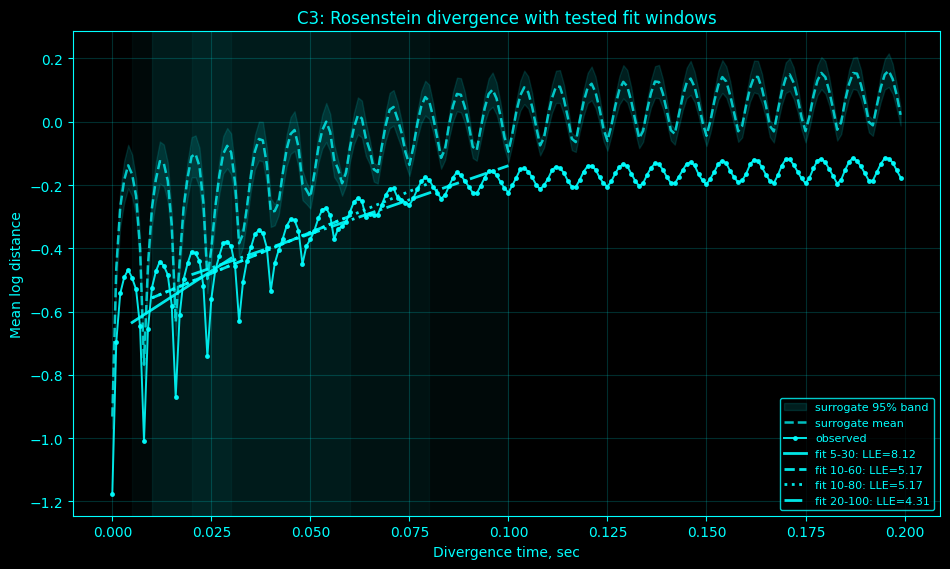

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/01_C3_divergence_fit_windows_C3_m10_tau8_tsep8_nS199_20260603_160047.png


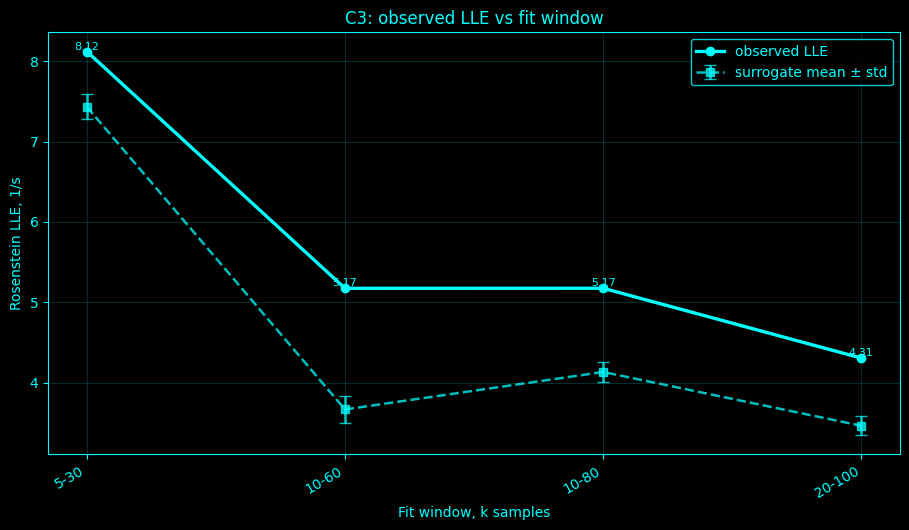

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/02_C3_LLE_vs_fit_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


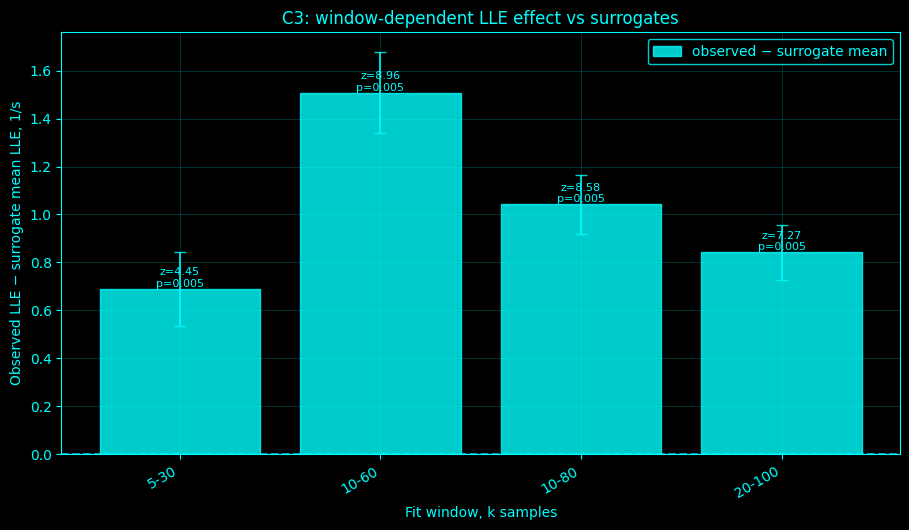

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/03_C3_LLE_effect_size_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


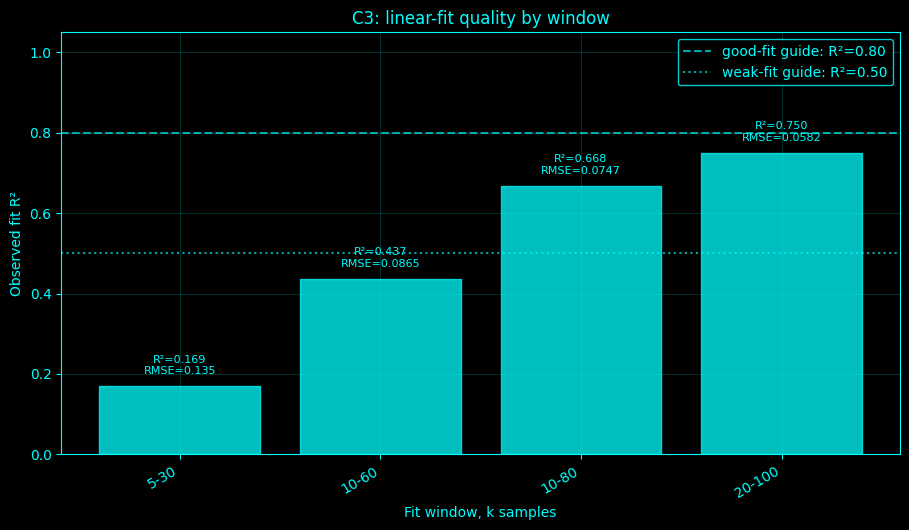

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/04_C3_fit_quality_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png


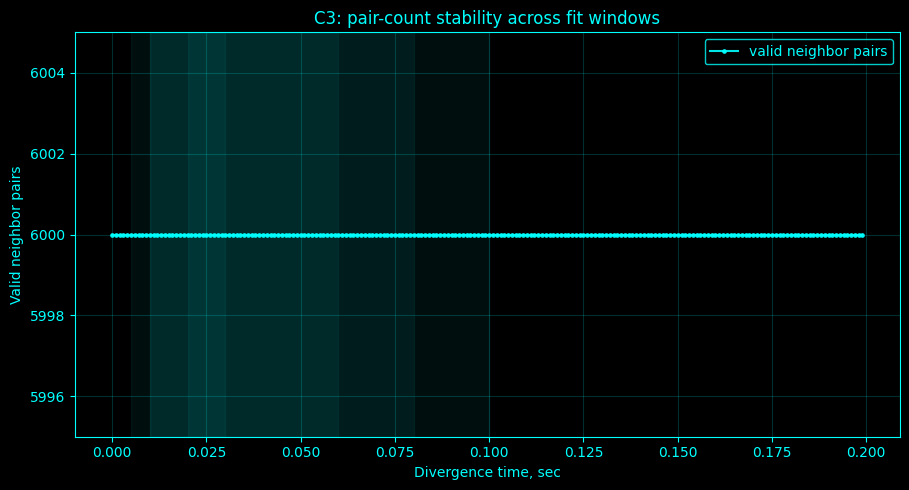

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/05_C3_pair_counts_by_k_C3_m10_tau8_tsep8_nS199_20260603_160047.png


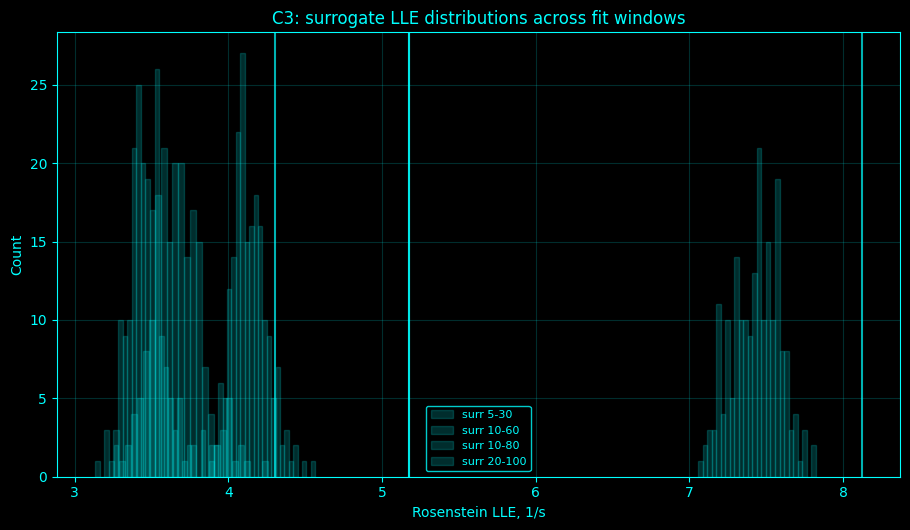

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/rosenstein_window_robustness_fast/plots/06_C3_surrogate_histograms_by_window_C3_m10_tau8_tsep8_nS199_20260603_160047.png

WINDOW ROBUSTNESS SUMMARY
channel  window_lo  window_hi window_label  window_lo_seconds  window_hi_seconds  LLE_obs  LLE_surr_mean  LLE_surr_std  LLE_surr_q025  LLE_surr_q975  delta_LLE  z_obs_vs_surrogates  p_one_surr_ge_obs  p_two_centered  fit_r2_obs  fit_rmse_obs  slope_obs_per_sample  fit_intercept_obs  pair_count_initial  fit_window_min_pair_count  fit_window_median_pair_count  pair_retention_percent  n_surrogates_requested  n_surrogates_completed  n_surrogates_failed  fs_eff  emb_dim  tau_eff  min_tsep_eff  kmax_eff  n_ref  k_query_base  iaaft_iters  iaaft_tol
     C3          5         30         5-30              0.005               0.03 8.121800       7.432570      0.154776       7.135871       7.732790   0.689230             4.453067              0.005           0.005    0.169146      0.13500

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "fast")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

channel_names = [
    "Fp1","Fpz","Fp2","F7","F3","Fz","F4","F8","FC5","FC1","FC2","FC6",
    "M1","T7","C3","Cz","C4","T8","M2","CP5","CP1","CP2","CP6",
    "P7","P3","Pz","P4","P8","POz","O1","Oz","O2"
]

CHANNELS = ["C3"]

fs_original = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * fs_original)
end_index = int(end_time * fs_original)

emb_dim = 10
tau_original = 8
min_tsep_original = 8
kmax_original = 200
n_ref = 6000
k_query_base = 120
min_pairs_required = 100

windows_original = [
    (5, 30),
    (10, 60),
    (10, 80),
    (20, 100)
]

n_surrogates = _speed_count(199, minimum=20)
iaaft_iters = 200
iaaft_tol = 1e-4
iaaft_min_iters = 80
iaaft_check_every = 20
seed = 0
n_workers = min(6, max(1, (os.cpu_count() or 2) - 1))

decimate_factor = 1
max_samples = None
standardize = True
linear_detrend = False

results_dir = os.path.join(base_dir, "results", "rosenstein_window_robustness_fast")
plots_dir = os.path.join(results_dir, "plots")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tag = f"C3_m{emb_dim}_tau{tau_original}_tsep{min_tsep_original}_nS{n_surrogates}_{timestamp}"

OUT_SUMMARY_CSV = os.path.join(results_dir, f"window_robustness_summary_{tag}.csv")
OUT_SURR_CSV = os.path.join(results_dir, f"window_robustness_surrogates_{tag}.csv")
OUT_CURVES_CSV = os.path.join(results_dir, f"window_robustness_curves_{tag}.csv")
OUT_QC_CSV = os.path.join(results_dir, f"window_robustness_qc_{tag}.csv")
OUT_NPZ = os.path.join(results_dir, f"window_robustness_arrays_{tag}.npz")
OUT_TXT = os.path.join(results_dir, f"window_robustness_report_{tag}.txt")

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, color=ACCENT, alpha=0.18)

def style_legend(leg):
    if leg is not None:
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(ACCENT)
        for text in leg.get_texts():
            text.set_color(ACCENT)

def save_show_close(fig, out_path, dpi=200):
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print("Saved:", out_path, flush=True)

def effective_sample_param(value_original, decimate_factor, minimum=1):
    return max(minimum, int(round(float(value_original) / float(decimate_factor))))

def effective_window(win_original, decimate_factor, kmax_eff):
    lo = effective_sample_param(win_original[0], decimate_factor, minimum=1)
    hi = effective_sample_param(win_original[1], decimate_factor, minimum=lo + 5)
    hi = min(hi, kmax_eff - 2)
    if hi <= lo + 4:
        hi = min(kmax_eff - 2, lo + 5)
    return int(lo), int(hi)

def linear_detrend_1d(x):
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x), dtype=float)
    coef = np.polyfit(t, x, 1)
    return x - np.polyval(coef, t)

def preprocess_signal(x, fs, decimate_factor=1, max_samples=None, standardize=True, detrend=False):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]
    fs_eff = float(fs)
    if detrend:
        x = linear_detrend_1d(x)
    if decimate_factor is not None and decimate_factor > 1:
        try:
            from scipy.signal import decimate
            x = decimate(x, int(decimate_factor), ftype="iir", zero_phase=True)
        except Exception:
            x = x[::int(decimate_factor)]
        fs_eff = fs_eff / float(decimate_factor)
    if max_samples is not None and len(x) > max_samples:
        start = max(0, (len(x) - max_samples) // 2)
        stop = start + max_samples
        x = x[start:stop]
    if standardize:
        x = x - np.mean(x)
        x = x / (np.std(x) + 1e-12)
    return x, fs_eff

def load_eeg_array(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing EEG file: {path}")
    arr = np.load(path, allow_pickle=True)
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {arr.shape}")
    if arr.shape[0] == len(channel_names) and arr.shape[1] != len(channel_names):
        arr = arr.T
    if arr.shape[1] != len(channel_names):
        raise ValueError(f"Expected {len(channel_names)} channels, got shape {arr.shape}")
    return arr

def get_channels_to_run():
    if CHANNELS is None:
        return list(channel_names)
    missing = [ch for ch in CHANNELS if ch not in channel_names]
    if len(missing) > 0:
        raise ValueError(f"Unknown requested channels: {missing}")
    return list(CHANNELS)

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    n = len(x)
    M = n - (m - 1) * tau
    if M <= 2:
        raise ValueError(f"Embedding failed: len={n}, m={m}, tau={tau}")
    return np.column_stack([x[i * tau:i * tau + M] for i in range(m)])

def spectrum_relative_error_from_mag(y, target_mag):
    mag_y = np.abs(np.fft.rfft(y))
    return float(np.linalg.norm(mag_y - target_mag) / (np.linalg.norm(target_mag) + 1e-12))

def iaaft_surrogate_fast(x_sorted, target_mag, n, seed, n_iter=200, tol=1e-4, min_iter=80, check_every=20):
    rng = np.random.default_rng(seed)
    y = rng.permutation(x_sorted)
    final_err = np.nan
    used_iters = 0
    for it in range(1, n_iter + 1):
        Y = np.fft.rfft(y)
        phase = np.exp(1j * np.angle(Y))
        y = np.fft.irfft(target_mag * phase, n=n)
        ranks = np.argsort(y, kind="quicksort")
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
        used_iters = it
        if it >= min_iter and ((it % check_every == 0) or (it == n_iter)):
            final_err = spectrum_relative_error_from_mag(y, target_mag)
            if final_err <= tol:
                break
    if not np.isfinite(final_err):
        final_err = spectrum_relative_error_from_mag(y, target_mag)
    return y, final_err, used_iters

def rosenstein_curve_fixed_tsep(x, m, tau, min_tsep, n_ref, kmax, seed=0, k_query_base=120, min_pairs_required=100):
    rng = np.random.default_rng(seed)
    X = delay_embed_1d(x, m, tau)
    M = len(X)
    valid_max = M - kmax - 1
    if valid_max <= 10:
        raise ValueError(f"Too few embedded points for kmax={kmax}. Embedded M={M}.")
    all_idx = np.arange(valid_max)
    if len(all_idx) > n_ref:
        ref_idx = np.sort(rng.choice(all_idx, size=n_ref, replace=False))
    else:
        ref_idx = all_idx
    k_query = min(M, max(k_query_base, int(min_tsep) + 40, 4 * m + 20))
    nn = NearestNeighbors(n_neighbors=k_query, algorithm="auto").fit(X)
    _, inds = nn.kneighbors(X[ref_idx])
    nn_idx = np.full(len(ref_idx), -1, dtype=int)
    for a, i in enumerate(ref_idx):
        for cand in inds[a, 1:]:
            cand = int(cand)
            if cand >= valid_max:
                continue
            if abs(cand - int(i)) > int(min_tsep):
                nn_idx[a] = cand
                break
    keep = nn_idx >= 0
    ref_keep = ref_idx[keep]
    nn_keep = nn_idx[keep]
    pair_count_initial = int(len(ref_keep))
    if pair_count_initial < min_pairs_required:
        raise ValueError(f"Too few pairs after Theiler exclusion: {pair_count_initial}")
    ks = np.arange(kmax, dtype=int)
    log_div = np.full(kmax, np.nan, dtype=float)
    counts = np.zeros(kmax, dtype=int)
    for k in range(kmax):
        i = ref_keep + k
        j = nn_keep + k
        ok = (i < M) & (j < M)
        if not np.any(ok):
            continue
        dist = np.linalg.norm(X[i[ok]] - X[j[ok]], axis=1)
        dist = np.maximum(dist, 1e-12)
        log_div[k] = float(np.mean(np.log(dist)))
        counts[k] = int(np.sum(ok))
    return ks, log_div, counts, pair_count_initial

def fit_curve_window(ks, log_div, lo, hi, fs_eff):
    lo = int(lo)
    hi = int(hi)
    if hi <= lo:
        raise ValueError(f"Invalid window: lo={lo}, hi={hi}")
    if hi >= len(ks):
        raise ValueError(f"Window hi={hi} outside k length {len(ks)}")
    xw = ks[lo:hi + 1]
    yw = log_div[lo:hi + 1]
    ok = np.isfinite(xw) & np.isfinite(yw)
    xw = xw[ok]
    yw = yw[ok]
    if len(xw) < 5:
        raise ValueError(f"Too few finite points in window {lo}-{hi}")
    coef = np.polyfit(xw, yw, 1)
    yhat = np.polyval(coef, xw)
    ss_res = float(np.sum((yw - yhat) ** 2))
    ss_tot = float(np.sum((yw - np.mean(yw)) ** 2))
    r2 = float(1.0 - ss_res / (ss_tot + 1e-12))
    rmse = float(np.sqrt(np.mean((yw - yhat) ** 2)))
    slope_per_sample = float(coef[0])
    intercept = float(coef[1])
    lle_per_second = float(slope_per_sample * fs_eff)
    return slope_per_sample, intercept, lle_per_second, r2, rmse

def fit_all_windows(ks, log_div, windows, fs_eff):
    out = {}
    for lo, hi in windows:
        slope, intercept, lle, r2, rmse = fit_curve_window(ks, log_div, lo, hi, fs_eff)
        out[(int(lo), int(hi))] = {
            "slope_per_sample": slope,
            "intercept": intercept,
            "LLE": lle,
            "fit_r2": r2,
            "fit_rmse": rmse,
        }
    return out

def empirical_p_values(obs, svals):
    svals = np.asarray(svals, dtype=float)
    svals = svals[np.isfinite(svals)]
    if len(svals) == 0 or not np.isfinite(obs):
        return np.nan, np.nan, np.nan
    mu = float(np.mean(svals))
    sd = float(np.std(svals, ddof=1) + 1e-12) if len(svals) > 1 else 1e-12
    z = float((obs - mu) / sd)
    p_high = float((np.sum(svals >= obs) + 1.0) / (len(svals) + 1.0))
    p_two_centered = float((np.sum(np.abs(svals - mu) >= abs(obs - mu)) + 1.0) / (len(svals) + 1.0))
    return z, p_high, p_two_centered

def add_fit_line(ax, ks, log_div, lo, hi, slope, intercept, fs_eff, label, linestyle="-"):
    kfit = ks[lo:hi + 1]
    yfit = slope * kfit + intercept
    ax.plot(kfit / fs_eff, yfit, color=ACCENT, linestyle=linestyle, linewidth=2.0, alpha=0.9, label=label)

tau_eff = effective_sample_param(tau_original, decimate_factor, minimum=1)
min_tsep_eff = effective_sample_param(min_tsep_original, decimate_factor, minimum=1)
kmax_eff = effective_sample_param(kmax_original, decimate_factor, minimum=20)
windows_eff = [effective_window(w, decimate_factor, kmax_eff) for w in windows_original]
windows_eff = sorted(set(windows_eff), key=lambda w: (w[0], w[1]))

print("Effective parameters:")
print("  decimate_factor:", decimate_factor)
print("  tau_eff:", tau_eff)
print("  min_tsep_eff:", min_tsep_eff)
print("  kmax_eff:", kmax_eff)
print("  windows_eff:", windows_eff)
print("  n_surrogates:", n_surrogates)
print("  iaaft_iters:", iaaft_iters)
print("  n_workers:", n_workers)

EEG = load_eeg_array(eeg_path)
channels_to_run = get_channels_to_run()

print("\nLoaded EEG:", eeg_path, flush=True)
print("EEG shape:", EEG.shape, flush=True)
print("Channels:", channels_to_run, flush=True)

summary_records = []
surrogate_records = []
curve_records = []
qc_records = []

npz_payload = {
    "channels": np.array(channels_to_run, dtype=object),
    "tau_eff": np.array([tau_eff], dtype=int),
    "min_tsep_eff": np.array([min_tsep_eff], dtype=int),
    "kmax_eff": np.array([kmax_eff], dtype=int),
    "windows_eff": np.array(windows_eff, dtype=int),
    "windows_original": np.array(windows_original, dtype=int),
    "fs_original": np.array([fs_original], dtype=float),
    "decimate_factor": np.array([decimate_factor], dtype=int),
    "n_surrogates": np.array([n_surrogates], dtype=int),
    "iaaft_iters": np.array([iaaft_iters], dtype=int),
}

run_start = time.time()

for ch_num, channel in enumerate(channels_to_run, start=1):
    print(f"\n[{ch_num}/{len(channels_to_run)}] Channel {channel}", flush=True)
    ch_i = channel_names.index(channel)
    x_raw = EEG[start_index:end_index, ch_i].astype(float)
    x, fs_eff = preprocess_signal(
        x_raw,
        fs=fs_original,
        decimate_factor=decimate_factor,
        max_samples=max_samples,
        standardize=standardize,
        detrend=linear_detrend
    )
    print(f"Loaded {channel}: N={len(x)} | fs_eff={fs_eff:g} Hz | segment=[{start_time},{end_time}] s", flush=True)
    ks_obs, ld_obs, counts_obs, pair_count_obs = rosenstein_curve_fixed_tsep(
        x,
        m=emb_dim,
        tau=tau_eff,
        min_tsep=min_tsep_eff,
        n_ref=n_ref,
        kmax=kmax_eff,
        seed=seed,
        k_query_base=k_query_base,
        min_pairs_required=min_pairs_required
    )
    obs_fits = fit_all_windows(ks_obs, ld_obs, windows_eff, fs_eff)
    print("Observed window fits:", flush=True)
    for win, fit in obs_fits.items():
        print(f"  k={win[0]}-{win[1]} | LLE={fit['LLE']:.6g} 1/s | R2={fit['fit_r2']:.4f} | RMSE={fit['fit_rmse']:.4g}", flush=True)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    n = len(x)
    surr_lle_by_window = {win: [] for win in windows_eff}
    surr_curve_stack = []
    surr_errors = []
    surr_iters = []
    def surrogate_worker(s):
        y, final_err, used_iters = iaaft_surrogate_fast(
            x_sorted=x_sorted,
            target_mag=target_mag,
            n=n,
            seed=seed + 10000 * ch_num + s,
            n_iter=iaaft_iters,
            tol=iaaft_tol,
            min_iter=iaaft_min_iters,
            check_every=iaaft_check_every
        )
        ks_s, ld_s, counts_s, pair_count_s = rosenstein_curve_fixed_tsep(
            y,
            m=emb_dim,
            tau=tau_eff,
            min_tsep=min_tsep_eff,
            n_ref=n_ref,
            kmax=kmax_eff,
            seed=seed + 1000 + s,
            k_query_base=k_query_base,
            min_pairs_required=min_pairs_required
        )
        fits_s = fit_all_windows(ks_s, ld_s, windows_eff, fs_eff)
        return {
            "surrogate_index": int(s + 1),
            "final_error": float(final_err),
            "used_iters": int(used_iters),
            "ks": ks_s,
            "log_div": ld_s,
            "counts": counts_s,
            "pair_count": int(pair_count_s),
            "fits": fits_s,
        }
    print(f"Running {n_surrogates} IAAFT surrogates with {n_workers} workers...", flush=True)
    completed = 0
    failed = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(surrogate_worker, s) for s in range(n_surrogates)]
        for fut in as_completed(futures):
            try:
                res = fut.result()
            except Exception as e:
                failed += 1
                print(f"  surrogate ERROR: {type(e).__name__}: {e}", flush=True)
                continue
            sidx = int(res["surrogate_index"])
            surr_errors.append(res["final_error"])
            surr_iters.append(res["used_iters"])
            surr_curve_stack.append(res["log_div"])
            for win in windows_eff:
                fit = res["fits"][win]
                surr_lle_by_window[win].append(fit["LLE"])
                surrogate_records.append({
                    "channel": channel,
                    "surrogate_index": sidx,
                    "window_lo": int(win[0]),
                    "window_hi": int(win[1]),
                    "window_label": f"{win[0]}-{win[1]}",
                    "LLE_surr": float(fit["LLE"]),
                    "slope_per_sample": float(fit["slope_per_sample"]),
                    "intercept": float(fit["intercept"]),
                    "fit_r2": float(fit["fit_r2"]),
                    "fit_rmse": float(fit["fit_rmse"]),
                    "pair_count": int(res["pair_count"]),
                    "iaaft_final_spectrum_relative_error": float(res["final_error"]),
                    "iaaft_iters_used": int(res["used_iters"]),
                })
            completed += 1
            if completed % 25 == 0 or completed + failed == n_surrogates:
                print(f"  completed {completed}/{n_surrogates} surrogates | failed={failed}", flush=True)
    for win in windows_eff:
        fit_obs = obs_fits[win]
        obs_val = float(fit_obs["LLE"])
        svals = np.asarray(surr_lle_by_window[win], dtype=float)
        svals = svals[np.isfinite(svals)]
        if len(svals) > 0:
            z, p_one, p_two = empirical_p_values(obs_val, svals)
            surr_mean = float(np.mean(svals))
            surr_std = float(np.std(svals, ddof=1)) if len(svals) > 1 else 0.0
            surr_q025 = float(np.percentile(svals, 2.5))
            surr_q975 = float(np.percentile(svals, 97.5))
        else:
            z, p_one, p_two = np.nan, np.nan, np.nan
            surr_mean, surr_std, surr_q025, surr_q975 = np.nan, np.nan, np.nan, np.nan
        fit_counts = counts_obs[win[0]:win[1] + 1]
        summary_records.append({
            "channel": channel,
            "window_lo": int(win[0]),
            "window_hi": int(win[1]),
            "window_label": f"{win[0]}-{win[1]}",
            "window_lo_seconds": float(win[0] / fs_eff),
            "window_hi_seconds": float(win[1] / fs_eff),
            "LLE_obs": obs_val,
            "LLE_surr_mean": surr_mean,
            "LLE_surr_std": surr_std,
            "LLE_surr_q025": surr_q025,
            "LLE_surr_q975": surr_q975,
            "delta_LLE": float(obs_val - surr_mean) if np.isfinite(surr_mean) else np.nan,
            "z_obs_vs_surrogates": float(z),
            "p_one_surr_ge_obs": float(p_one),
            "p_two_centered": float(p_two),
            "fit_r2_obs": float(fit_obs["fit_r2"]),
            "fit_rmse_obs": float(fit_obs["fit_rmse"]),
            "slope_obs_per_sample": float(fit_obs["slope_per_sample"]),
            "fit_intercept_obs": float(fit_obs["intercept"]),
            "pair_count_initial": int(pair_count_obs),
            "fit_window_min_pair_count": int(np.nanmin(fit_counts)) if len(fit_counts) else -1,
            "fit_window_median_pair_count": float(np.nanmedian(fit_counts)) if len(fit_counts) else np.nan,
            "pair_retention_percent": float(100.0 * np.nanmin(fit_counts) / max(pair_count_obs, 1)) if len(fit_counts) else np.nan,
            "n_surrogates_requested": int(n_surrogates),
            "n_surrogates_completed": int(len(svals)),
            "n_surrogates_failed": int(failed),
            "fs_eff": float(fs_eff),
            "emb_dim": int(emb_dim),
            "tau_eff": int(tau_eff),
            "min_tsep_eff": int(min_tsep_eff),
            "kmax_eff": int(kmax_eff),
            "n_ref": int(n_ref),
            "k_query_base": int(k_query_base),
            "iaaft_iters": int(iaaft_iters),
            "iaaft_tol": float(iaaft_tol),
        })
    surr_curve_stack = np.asarray(surr_curve_stack, dtype=float)
    for k in range(kmax_eff):
        rec = {
            "channel": channel,
            "k": int(k),
            "time_seconds": float(k / fs_eff),
            "observed_log_div": float(ld_obs[k]),
            "observed_count": int(counts_obs[k]),
        }
        if surr_curve_stack.size > 0:
            rec.update({
                "surrogate_mean_log_div": float(np.nanmean(surr_curve_stack[:, k])),
                "surrogate_std_log_div": float(np.nanstd(surr_curve_stack[:, k])),
                "surrogate_q025_log_div": float(np.nanpercentile(surr_curve_stack[:, k], 2.5)),
                "surrogate_q975_log_div": float(np.nanpercentile(surr_curve_stack[:, k], 97.5)),
            })
        else:
            rec.update({
                "surrogate_mean_log_div": np.nan,
                "surrogate_std_log_div": np.nan,
                "surrogate_q025_log_div": np.nan,
                "surrogate_q975_log_div": np.nan,
            })
        curve_records.append(rec)
    qc_records.append({
        "channel": channel,
        "n_samples_used": int(len(x)),
        "fs_eff": float(fs_eff),
        "duration_seconds_used": float(len(x) / fs_eff),
        "x_mean": float(np.mean(x)),
        "x_std": float(np.std(x)),
        "x_min": float(np.min(x)),
        "x_q01": float(np.percentile(x, 1)),
        "x_q25": float(np.percentile(x, 25)),
        "x_median": float(np.median(x)),
        "x_q75": float(np.percentile(x, 75)),
        "x_q99": float(np.percentile(x, 99)),
        "x_max": float(np.max(x)),
        "observed_pair_count": int(pair_count_obs),
        "mean_iaaft_error": float(np.mean(surr_errors)) if len(surr_errors) else np.nan,
        "max_iaaft_error": float(np.max(surr_errors)) if len(surr_errors) else np.nan,
        "mean_iaaft_iters_used": float(np.mean(surr_iters)) if len(surr_iters) else np.nan,
        "max_iaaft_iters_used": int(np.max(surr_iters)) if len(surr_iters) else -1,
        "surrogates_completed": int(completed),
        "surrogates_failed": int(failed),
    })
    npz_payload[f"{channel}_ks"] = ks_obs
    npz_payload[f"{channel}_obs_log_div"] = ld_obs
    npz_payload[f"{channel}_obs_counts"] = counts_obs
    if surr_curve_stack.size > 0:
        npz_payload[f"{channel}_surr_log_div"] = surr_curve_stack
    for win in windows_eff:
        npz_payload[f"{channel}_surr_lle_window_{win[0]}_{win[1]}"] = np.asarray(surr_lle_by_window[win], dtype=float)
    summary_ch = pd.DataFrame([r for r in summary_records if r["channel"] == channel]).sort_values(["window_lo", "window_hi"])
    fig, ax = plt.subplots(figsize=(9.6, 5.8), facecolor=BG)
    style_ax(ax)
    if surr_curve_stack.size > 0:
        s_mean = np.nanmean(surr_curve_stack, axis=0)
        s_q025 = np.nanpercentile(surr_curve_stack, 2.5, axis=0)
        s_q975 = np.nanpercentile(surr_curve_stack, 97.5, axis=0)
        ax.fill_between(ks_obs / fs_eff, s_q025, s_q975, color=ACCENT, alpha=0.12, label="surrogate 95% band")
        ax.plot(ks_obs / fs_eff, s_mean, color=ACCENT, linestyle="--", linewidth=1.8, alpha=0.75, label="surrogate mean")
    ax.plot(ks_obs / fs_eff, ld_obs, color=ACCENT, marker="o", markersize=2.5, linewidth=1.4, alpha=0.9, label="observed")
    linestyles = ["-", "--", ":", "-."]
    for wi, win in enumerate(windows_eff):
        fit = obs_fits[win]
        add_fit_line(
            ax,
            ks_obs,
            ld_obs,
            win[0],
            win[1],
            fit["slope_per_sample"],
            fit["intercept"],
            fs_eff,
            label=f"fit {win[0]}-{win[1]}: LLE={fit['LLE']:.2f}",
            linestyle=linestyles[wi % len(linestyles)]
        )
        ax.axvspan(win[0] / fs_eff, win[1] / fs_eff, color=ACCENT, alpha=0.04)
    ax.set_title(f"{channel}: Rosenstein divergence with tested fit windows")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Mean log distance")
    leg = ax.legend(loc="best", fontsize=8)
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"01_{channel}_divergence_fit_windows_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    xpos = np.arange(len(summary_ch))
    labels = summary_ch["window_label"].values
    ax.errorbar(
        xpos,
        summary_ch["LLE_surr_mean"],
        yerr=summary_ch["LLE_surr_std"],
        color=ACCENT,
        linestyle="--",
        marker="s",
        capsize=4,
        linewidth=1.8,
        alpha=0.75,
        label="surrogate mean ± std"
    )
    ax.plot(
        xpos,
        summary_ch["LLE_obs"],
        color=ACCENT,
        marker="o",
        linewidth=2.4,
        label="observed LLE"
    )
    for i, row in summary_ch.iterrows():
        ax.text(
            list(summary_ch.index).index(i),
            row["LLE_obs"],
            f"{row['LLE_obs']:.2f}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{channel}: observed LLE vs fit window")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Rosenstein LLE, 1/s")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"02_{channel}_LLE_vs_fit_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    ax.bar(
        xpos,
        summary_ch["delta_LLE"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8,
        label="observed − surrogate mean"
    )
    ax.errorbar(
        xpos,
        summary_ch["delta_LLE"],
        yerr=summary_ch["LLE_surr_std"],
        fmt="none",
        ecolor=ACCENT,
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )
    ax.axhline(0, color=ACCENT, linestyle="--", alpha=0.65)
    for i, row in summary_ch.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["delta_LLE"],
            f"z={row['z_obs_vs_surrogates']:.2f}\np={row['p_one_surr_ge_obs']:.4g}",
            color=ACCENT,
            ha="center",
            va="bottom" if row["delta_LLE"] >= 0 else "top",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{channel}: window-dependent LLE effect vs surrogates")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Observed LLE − surrogate mean LLE, 1/s")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"03_{channel}_LLE_effect_size_by_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    ax.bar(
        xpos,
        summary_ch["fit_r2_obs"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.75
    )
    ax.axhline(0.80, color=ACCENT, linestyle="--", alpha=0.65, label="good-fit guide: R²=0.80")
    ax.axhline(0.50, color=ACCENT, linestyle=":", alpha=0.65, label="weak-fit guide: R²=0.50")
    for i, row in summary_ch.reset_index(drop=True).iterrows():
        ax.text(
            i,
            row["fit_r2_obs"] + 0.025,
            f"R²={row['fit_r2_obs']:.3f}\nRMSE={row['fit_rmse_obs']:.3g}",
            color=ACCENT,
            ha="center",
            va="bottom",
            fontsize=8
        )
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{channel}: linear-fit quality by window")
    ax.set_xlabel("Fit window, k samples")
    ax.set_ylabel("Observed fit R²")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"04_{channel}_fit_quality_by_window_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.0), facecolor=BG)
    style_ax(ax)
    ax.plot(
        ks_obs / fs_eff,
        counts_obs,
        color=ACCENT,
        marker="o",
        markersize=2.4,
        linewidth=1.5,
        alpha=0.9,
        label="valid neighbor pairs"
    )
    for win in windows_eff:
        ax.axvspan(win[0] / fs_eff, win[1] / fs_eff, color=ACCENT, alpha=0.06)
    cmin = float(np.nanmin(counts_obs))
    cmax = float(np.nanmax(counts_obs))
    pad = max(5.0, 0.03 * max(abs(cmax - cmin), 1.0))
    ax.set_ylim(cmin - pad, cmax + pad)
    ax.set_title(f"{channel}: pair-count stability across fit windows")
    ax.set_xlabel("Divergence time, sec")
    ax.set_ylabel("Valid neighbor pairs")
    leg = ax.legend()
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"05_{channel}_pair_counts_by_k_{tag}.png")
    save_show_close(fig, plot_path)
    fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=BG)
    style_ax(ax)
    for win in windows_eff:
        svals = np.asarray(surr_lle_by_window[win], dtype=float)
        ax.hist(
            svals,
            bins=min(26, max(10, int(np.sqrt(len(svals)) * 2))),
            alpha=0.18,
            color=ACCENT,
            edgecolor=ACCENT,
            label=f"surr {win[0]}-{win[1]}"
        )
        ax.axvline(obs_fits[win]["LLE"], color=ACCENT, linewidth=1.5, alpha=0.7)
    ax.set_title(f"{channel}: surrogate LLE distributions across fit windows")
    ax.set_xlabel("Rosenstein LLE, 1/s")
    ax.set_ylabel("Count")
    leg = ax.legend(fontsize=8)
    style_legend(leg)
    plot_path = os.path.join(plots_dir, f"06_{channel}_surrogate_histograms_by_window_{tag}.png")
    save_show_close(fig, plot_path)

summary_df = pd.DataFrame(summary_records)
surrogate_df = pd.DataFrame(surrogate_records)
curve_df = pd.DataFrame(curve_records)
qc_df = pd.DataFrame(qc_records)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
surrogate_df.to_csv(OUT_SURR_CSV, index=False)
curve_df.to_csv(OUT_CURVES_CSV, index=False)
qc_df.to_csv(OUT_QC_CSV, index=False)

npz_payload["summary_json"] = np.array([summary_df.to_json(orient="records")], dtype=object)
npz_payload["surrogate_json"] = np.array([surrogate_df.to_json(orient="records")], dtype=object)
npz_payload["curve_json"] = np.array([curve_df.to_json(orient="records")], dtype=object)
npz_payload["qc_json"] = np.array([qc_df.to_json(orient="records")], dtype=object)

np.savez_compressed(OUT_NPZ, **npz_payload)

with open(OUT_TXT, "w") as f:
    f.write("Fast Rosenstein Fit-Window Robustness with IAAFT Surrogates\n")
    f.write("==========================================================\n\n")
    f.write(f"timestamp={timestamp}\n")
    f.write(f"eeg_path={eeg_path}\n")
    f.write(f"channels={channels_to_run}\n")
    f.write(f"segment=[{start_time},{end_time}] sec\n")
    f.write(f"fs_original={fs_original}\n")
    f.write(f"decimate_factor={decimate_factor}\n")
    f.write(f"emb_dim={emb_dim}\n")
    f.write(f"tau_eff={tau_eff}\n")
    f.write(f"min_tsep_eff={min_tsep_eff}\n")
    f.write(f"kmax_eff={kmax_eff}\n")
    f.write(f"windows_eff={windows_eff}\n")
    f.write(f"n_ref={n_ref}\n")
    f.write(f"k_query_base={k_query_base}\n")
    f.write(f"n_surrogates={n_surrogates}\n")
    f.write(f"iaaft_iters={iaaft_iters}\n")
    f.write(f"iaaft_tol={iaaft_tol}\n")
    f.write(f"n_workers={n_workers}\n\n")
    f.write("Summary:\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nQC:\n")
    f.write(qc_df.to_string(index=False))

print("\n==============================")
print("WINDOW ROBUSTNESS SUMMARY")
print("==============================")
print(summary_df.to_string(index=False))

print("\nQC:")
print(qc_df.to_string(index=False))

print("\nSaved outputs:")
print("Summary CSV:", OUT_SUMMARY_CSV)
print("Surrogate CSV:", OUT_SURR_CSV)
print("Curve CSV:", OUT_CURVES_CSV)
print("QC CSV:", OUT_QC_CSV)
print("NPZ:", OUT_NPZ)
print("TXT:", OUT_TXT)
print("Plots:", plots_dir)
print(f"Elapsed: {(time.time() - run_start) / 60:.2f} minutes")
print("Done.")

### Kantz LLE + IAAFT surrogate comparison

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>
            This block provides a reproducible Kantz-method workflow for estimating the largest Lyapunov exponent (LLE) from an EEG segment and comparing that estimate
            against an ensemble of IAAFT surrogates. It loads a scalar time series from one channel (<code>C3</code>), standardizes the signal, reconstructs the
            delay-embedded state space, computes the Kantz mean-log-divergence curve using multiple neighbors per reference point, fits a linear region of that curve to
            estimate the observed LLE, and then repeats the same procedure on <code>199</code> IAAFT surrogates. The key intent is to test whether the observed
            divergence rate is unusually large relative to surrogate signals that preserve the amplitude distribution and approximately preserve the power spectrum.
        </p>
        <h2>Mathematical Foundations</h2>
        <p>
            The Kantz method estimates the largest Lyapunov exponent by following the average divergence of local neighborhoods in reconstructed phase space. For a
            reference point <code>x_i</code> and a set of valid neighbors <code>\(\mathcal{N}(i)\)</code>, the average future divergence after <code>k</code> steps is
            summarized by:
        </p>
        \[
            y(k)=\left\langle \log\left(\frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} \|X_{i+k}-X_{j+k}\|\right)\right\rangle_i
        \]
        <p>
            In a regime of exponential divergence, this behaves approximately linearly:
        </p>
        \[
            y(k)\approx c+\lambda k\Delta t
        \]
        <p>
            where <code>\(\lambda\)</code> is the largest Lyapunov exponent and <code>\(\Delta t = 1/fs\)</code>. The code fits <code>y(k)</code> over a selected
            window <code>k=[10,60]</code> samples, estimates the slope per sample, and multiplies by the sampling rate to express the final LLE in physical units of
            <code>1/s</code>.
        </p>
        <h2>Delay Embedding and Neighbor Structure</h2>
        <p>
            The scalar signal is reconstructed into delay vectors using embedding dimension <code>m=10</code> and delay <code>\(\tau=8\)</code>:
        </p>
        \[
            X_t=[x_t,\;x_{t+\tau},\;x_{t+2\tau},\;\dots,\;x_{t+(m-1)\tau}]
        \]
        <p>
            Unlike Rosenstein-style estimation, which typically uses one nearest neighbor per reference point, the Kantz method averages divergence over
            <code>K_use=20</code> neighbors per reference. This can make the divergence curve more stable by reducing sensitivity to any single neighbor pairing. The
            code first requests up to <code>K_search=400</code> candidate neighbors, then filters them according to self-exclusion, Theiler separation, and forward
            index validity before keeping the first <code>K_use</code> usable neighbors.
        </p>
        <h2>Critical Index-Safety Fix</h2>
        <p>
            A central feature of this implementation is the explicit requirement that both the reference index <code>i</code> and every chosen neighbor index
            <code>j</code> must remain valid for all forward evolution steps up to <code>kmax_eff</code>. In other words, both must satisfy
            <code>i + kmax_eff &lt; M</code> and <code>j + kmax_eff &lt; M</code>. This prevents out-of-bounds access when evaluating
            <code>X[i+k]</code> and <code>X[j+k]</code> and ensures that every pair contributes valid future trajectories throughout the full divergence calculation.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Implementation Synopsis</h2>
        <p>
            The pipeline is:
            <ol>
                <li><b>Load</b> the selected EEG channel and extract the target time segment.</li>
                <li><b>Standardize</b> the scalar signal with a z-score transform.</li>
                <li><b>Embed</b> the signal in delay-coordinate space with <code>m=10</code> and <code>tau=8</code>.</li>
                <li><b>Select</b> reference points and candidate neighbors in embedded space using nearest-neighbor search.</li>
                <li><b>Filter</b> neighbors by self-removal, Theiler separation, and forward-validity constraints.</li>
                <li><b>Compute</b> the Kantz mean-log-divergence curve by averaging log distances across neighbors and reference points.</li>
                <li><b>Fit</b> the divergence curve over the chosen window <code>k=[10,60]</code> to estimate the observed LLE.</li>
                <li><b>Generate</b> <code>199</code> IAAFT surrogates and repeat the identical Kantz analysis for each surrogate.</li>
                <li><b>Compute</b> a one-sided empirical p-value comparing surrogate LLEs against the observed LLE.</li>
                <li><b>Save</b> structured outputs, summary text, divergence and histogram plots, and the full surrogate result array.</li>
            </ol>
            This makes the script both an LLE-estimation workflow and a surrogate-based significance test under fixed embedding and neighbor-selection rules.
        </p>
        <h2>IAAFT Surrogates and Null Model</h2>
        <p>
            The surrogate generator uses the Iterative Amplitude Adjusted Fourier Transform method. Each surrogate is initialized from a random permutation of the
            original signal and then iteratively alternates between:
            <ul>
                <li><b>Spectrum enforcement:</b> replacing the surrogate Fourier magnitudes with the original magnitudes while keeping surrogate phases,</li>
                <li><b>Amplitude enforcement:</b> rank-order remapping so the surrogate matches the original amplitude distribution.</li>
            </ul>
            The resulting surrogates preserve the marginal distribution exactly and approximate the original power spectrum, while disrupting nonlinear temporal
            structure. This provides a constrained null model for testing whether the observed Kantz LLE is unusually large.
        </p>
        <h2>Hypothesis Test and Interpretability</h2>
        <p>
            After computing the observed LLE and the surrogate LLE ensemble, the code evaluates a one-sided empirical p-value:
        </p>
        \[
            p_{\mathrm{one}}=\frac{\#\{\,\lambda_{\mathrm{surr}}\ge\lambda_{\mathrm{obs}}\,\}+1}{n_{\mathrm{surr}}+1}
        \]
        <p>
            This quantity measures how often a surrogate produces an LLE at least as large as the observed signal. A small value indicates that the observed divergence
            rate is unusually large relative to the surrogate null distribution, providing evidence that the original signal contains stronger divergence structure than
            expected from a linearized surrogate process with matched spectrum and histogram.
        </p>
        <h2>Axis Semantics</h2>
        <p>
            <ul>
                <li><b>x-axis in the divergence plot:</b> forward step index <code>k</code> in samples.</li>
                <li><b>y-axis in the divergence plot:</b> mean log distance across reference-neighbor ensembles.</li>
                <li><b>Shaded region:</b> the fit window <code>k=[10,60]</code> used for regression.</li>
                <li><b>Fit line:</b> the linear approximation whose slope determines the observed LLE.</li>
                <li><b>x-axis in the histogram plot:</b> surrogate LLE values in <code>1/s</code>.</li>
                <li><b>Vertical line in the histogram:</b> the observed Kantz LLE.</li>
            </ul>
            Together, these figures show both the geometry of divergence in reconstructed space and the position of the observed estimate relative to the surrogate
            null distribution.
        </p>
        <h2>Practical Interpretation</h2>
        <p>
            This view is most useful for:
            <ul>
                <li>Estimating the largest Lyapunov exponent with neighborhood averaging rather than single-neighbor divergence,</li>
                <li>Testing whether the observed LLE is unusually large compared with IAAFT surrogates,</li>
                <li>Checking that neighbor selection remains valid for all forward evolution steps,</li>
                <li>Saving an auditable record of divergence curves, surrogate distributions, and fitted results.</li>
            </ul>
            In practice, a positive observed LLE together with a small one-sided surrogate p-value suggests stronger instability or divergence structure than would be
            expected under the chosen surrogate null model. However, as with all surrogate-based dynamical tests, this supports nontrivial structure rather than proving
            deterministic chaos by itself.
        </p>
        <h2>Reproducibility Tip</h2>
        <p>
            The script fixes the random seed, records the channel, segment, embedding parameters, Theiler separation, neighbor settings, surrogate count, and fit window
            in the saved outputs, and stores both raw arrays and human-readable summary text. Because the forward-validity constraints are enforced explicitly for both
            references and neighbors, the resulting Kantz analysis can be rerun reliably without hidden indexing failures.
        </p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Delay embedding turns one measured time series into a sequence of state-space vectors by combining the present sample with delayed copies of the same signal. The idea is that the hidden state of a dynamical system can sometimes be reconstructed from a single observable when enough delayed coordinates are used. The delay controls how far apart in time the coordinates are, while the embedding dimension controls how many delayed coordinates are included. Too small a delay makes coordinates nearly redundant; too large a delay can make them weakly related. Too small an embedding dimension can fold distinct states onto one another.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>
